# Session Learning Curve

**Goal**: Characterize how decision-making signatures evolve across visits, using session-level behavioral and physiological features rather than LOSO classification accuracy.

**Two analysis tracks**:

1. **Equalized-N paired design** — sample a matched subset of subjects from V1 and V2 to balance trial counts, then compare V1 vs V2 vs V3 at the subject level (not pooled-session level). For the full 3-visit trajectory, restrict to the 8 subjects who completed all 3 visits.

2. **Behavioral / physiological signatures as learning metrics** — rather than classification accuracy, compute per-session-per-subject values of theoretically motivated features:
   - `log_odds_invest`: logit of invest rate — how extreme (committed) is the policy
   - `ev_sensitivity`: slope of invest rate on EV difference — is the subject becoming better calibrated?
   - `ambiguity_aversion`: invest rate gap between unambiguous (amb=0) and ambiguous (amb>0) trials
   - `choice_momentum`: logistic regression coefficient for previous outcome predicting current choice
   - `rt_mean` / `rt_cv`: decision speed and variability
   - Pupil: `pupil_mean_pre`, `pupil_cv_pre` — arousal and uncertainty tracking
   - Gaze: `fixation_ratio`, `saccade_count` — visual exploration strategy

   Then fit LMM: `signature ~ visit_number + (1|subject) + (1|team)`

In [13]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.special import logit
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from src.utils.io import load_features

RESULTS_DIR = Path('../../data/results/main/learning_curve')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TIMEFRAME = 'PRE'
RANDOM_STATE = 42

## 1. Load Data

In [14]:
feature_data = load_features(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', timeframe=TIMEFRAME)

df = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Restrict to the 80-subject EEG set
EEG_ACC_PATH = '../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv'
eeg_subjects = set(pd.read_csv(EEG_ACC_PATH)['subject_id'])
df = df[df['subject_id'].isin(eeg_subjects)].copy()

# Add visit info from corrected session_mapping
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']

df = df.merge(sm[['subject_id', 'visit_number', 'team', 'user_id']], on='subject_id', how='left')

print(f"Total trials: {len(df)}, subjects: {df['subject_id'].nunique()} (EEG set only)")
print("Trials per visit:")
print(df['visit_number'].value_counts().sort_index())
print(f"NaN visit: {df['visit_number'].isna().sum()} trials (sessions not in session_mapping)")

Total trials: 9618, subjects: 80 (EEG set only)
Trials per visit:
visit_number
1.0    4597
2.0    3704
3.0    1317
Name: count, dtype: int64
NaN visit: 0 trials (sessions not in session_mapping)


## 2. Subject-Level Design

Build two matched cohorts:
- **Full 3-visit cohort**: 8 subjects (same desktop ID × team) with data at V1, V2, V3
- **V1+V2 equalized cohort**: 33 matched pairs; sample 8 from V1 to match V3 N for fair comparison

In [15]:
# --- Build matched subject table ---
v12_teams = [t for t in sm['team'].unique()
             if (sm[sm['team']==t]['visit_number'] == 1.0).any()
             and (sm[sm['team']==t]['visit_number'] == 2.0).any()]
three_visit_teams = [t for t in v12_teams
                     if (sm[sm['team']==t]['visit_number'] == 3.0).any()]

print(f"Teams with V1+V2: {sorted(v12_teams)}")
print(f"Teams with V1+V2+V3: {sorted(three_visit_teams)}")

def get_subject_id(team, user_id, visit):
    row = sm[(sm['team']==team) & (sm['user_id']==user_id) & (sm['visit_number']==visit)]
    return row['subject_id'].values[0] if len(row) else None

# 3-visit cohort
records_3v = []
for team in three_visit_teams:
    uids_all = set(sm[(sm['team']==team) & (sm['visit_number']==1.0)]['user_id']) & \
               set(sm[(sm['team']==team) & (sm['visit_number']==2.0)]['user_id']) & \
               set(sm[(sm['team']==team) & (sm['visit_number']==3.0)]['user_id'])
    for uid in uids_all:
        records_3v.append({'team': team, 'user_id': uid,
                           'subj_v1': get_subject_id(team, uid, 1.0),
                           'subj_v2': get_subject_id(team, uid, 2.0),
                           'subj_v3': get_subject_id(team, uid, 3.0)})

cohort_3v = pd.DataFrame(records_3v)
print(f"\n3-visit cohort: {len(cohort_3v)} subjects")
print(cohort_3v.to_string(index=False))

# V1+V2 matched pairs (all teams with both visits)
records_2v = []
for team in v12_teams:
    uids = set(sm[(sm['team']==team) & (sm['visit_number']==1.0)]['user_id']) & \
           set(sm[(sm['team']==team) & (sm['visit_number']==2.0)]['user_id'])
    for uid in uids:
        records_2v.append({'team': team, 'user_id': uid,
                           'subj_v1': get_subject_id(team, uid, 1.0),
                           'subj_v2': get_subject_id(team, uid, 2.0)})

cohort_2v = pd.DataFrame(records_2v)
print(f"\nV1+V2 matched pairs: {len(cohort_2v)} subjects")

Teams with V1+V2: ['Team 12', 'Team 15', 'Team 16', 'Team 17', 'Team 18', 'Team 20', 'Team 21', 'Team 22', 'Team 23', 'Team 24', 'Team 25', 'Team 26', 'Team 4']
Teams with V1+V2+V3: ['Team 17', 'Team 21', 'Team 22', 'Team 24']

3-visit cohort: 11 subjects
   team user_id           subj_v1           subj_v2           subj_v3
Team 24 539136F 0920_1600_539136F 0923_1600_539136F 0924_1600_539136F
Team 24 9M4VCHG 0920_1600_9M4VCHG 0923_1600_9M4VCHG 0924_1600_9M4VCHG
Team 24 U9TEJGM 0920_1600_U9TEJGM 0923_1600_U9TEJGM 0924_1600_U9TEJGM
Team 17 539136F 0824_1000_539136F 0825_1000_539136F 0826_1000_539136F
Team 17 9M4VCHG 0824_1000_9M4VCHG 0825_1000_9M4VCHG 0826_1000_9M4VCHG
Team 22 539136F 0915_1000_539136F 0917_1030_539136F 0924_1000_539136F
Team 22 9M4VCHG 0915_1000_9M4VCHG 0917_1030_9M4VCHG 0924_1000_9M4VCHG
Team 22 U9TEJGM 0915_1000_U9TEJGM 0917_1030_U9TEJGM 0924_1000_U9TEJGM
Team 21 539136F 0830_1300_539136F 0831_1300_539136F 0901_1300_539136F
Team 21 9M4VCHG 0830_1300_9M4VCHG 0831_1300_

## 3. Compute Per-Session Behavioral Signatures

For each subject × visit, compute:
- **`log_odds_invest`**: logit(mean invest rate) — policy commitment
- **`ev_sensitivity`**: Spearman ρ of outcome ~ ev_difference — EV calibration
- **`ambiguity_aversion`**: invest rate(amb=0) − invest rate(amb>0)
- **`choice_momentum`**: Spearman ρ of outcome ~ prev_outcome — perseveration
- **`rt_mean`**, **`rt_cv`**: response speed and variability
- Pupil: **`pupil_mean`**, **`pupil_cv`**
- Gaze: **`fixation_ratio`**, **`saccade_count`**

In [16]:
def safe_logit(p, eps=1e-3):
    p = np.clip(p, eps, 1 - eps)
    return float(np.log(p / (1 - p)))


def session_signatures(trials):
    """Compute learning-curve signatures for one subject × visit."""
    if len(trials) < 10:
        return None

    out = {}
    out['n_trials'] = len(trials)

    # Behavioral
    invest_rate = trials['outcome'].mean()
    out['invest_rate'] = invest_rate
    out['log_odds_invest'] = safe_logit(invest_rate)

    ev = trials['ev_difference'].values
    y = trials['outcome'].values
    out['ev_sensitivity'] = stats.spearmanr(ev, y, nan_policy='omit').statistic

    amb0 = trials[trials['ambiguity'] == 0]['outcome'].mean()
    ambpos = trials[trials['ambiguity'] > 0]['outcome'].mean()
    out['ambiguity_aversion'] = (amb0 - ambpos) if (not np.isnan(amb0) and not np.isnan(ambpos)) else np.nan

    prev = trials['prev_outcome'].values
    out['choice_momentum'] = stats.spearmanr(prev, y, nan_policy='omit').statistic

    rt = trials['decision_time'].values
    out['rt_mean'] = np.nanmean(rt)
    out['rt_cv'] = np.nanstd(rt) / np.nanmean(rt) if np.nanmean(rt) > 0 else np.nan

    # Physiology
    out['pupil_mean'] = trials['pupil_mean_pre'].mean()
    out['pupil_cv'] = trials['pupil_cv_pre'].mean()

    # Gaze
    out['fixation_ratio'] = trials['fixation_ratio'].mean()
    out['saccade_count'] = trials['saccade_count'].mean()

    return out


def build_signature_df(df_trials):
    rows = []
    for subj, grp in df_trials.groupby('subject_id'):
        meta = grp[['visit_number', 'team', 'user_id']].iloc[0]
        sigs = session_signatures(grp)
        if sigs is None:
            continue
        rows.append({'subject_id': subj,
                     'visit_number': meta['visit_number'],
                     'team': meta['team'],
                     'user_id': meta['user_id'],
                     **sigs})
    return pd.DataFrame(rows)


sig_df = build_signature_df(df[df['visit_number'].notna()])
print(f"Signature rows: {len(sig_df)} (subjects × visit)")
print(sig_df.groupby('visit_number')[['invest_rate','ev_sensitivity','rt_mean','pupil_mean']].mean().round(3))

Signature rows: 80 (subjects × visit)
              invest_rate  ev_sensitivity  rt_mean  pupil_mean
visit_number                                                  
1.0                 0.612           0.093    2.596       0.403
2.0                 0.692           0.115    2.198       0.402
3.0                 0.683           0.221    1.920       0.449


## 4. Equalized-N Balanced Comparison

**Problem**: V1 has 51 sessions, V2 has 34, V3 has 8 — so raw visit-level means confound group size with signal.

**Solution A** — *3-visit cohort*: use only the 8 subjects with all 3 visits. Fully paired, maximum control.

**Solution B** — *Subsampled V1*: from the 33 V1+V2 matched pairs, randomly sample 8 per-team-balanced subjects from V1 to match V3 N, repeat 100× and average. Shows whether V1→V2 shift is robust to subsampling.

In [17]:
# --- Solution A: 3-visit cohort signatures ---
subjs_3v = pd.concat([
    cohort_3v[['team','user_id','subj_v1']].rename(columns={'subj_v1':'subject_id'}),
    cohort_3v[['team','user_id','subj_v2']].rename(columns={'subj_v2':'subject_id'}),
    cohort_3v[['team','user_id','subj_v3']].rename(columns={'subj_v3':'subject_id'}),
])['subject_id'].dropna().unique()

sig_3v = sig_df[sig_df['subject_id'].isin(subjs_3v)].copy()
sig_3v['cohort'] = '3-visit'

print("3-visit cohort — signatures per visit:")
print(sig_3v.groupby('visit_number')[['invest_rate','ev_sensitivity','ambiguity_aversion',
                                      'choice_momentum','rt_mean','pupil_mean']].mean().round(3))

3-visit cohort — signatures per visit:
              invest_rate  ev_sensitivity  ambiguity_aversion  \
visit_number                                                    
1.0                 0.606           0.159               0.408   
2.0                 0.704           0.148               0.260   
3.0                 0.683           0.221               0.136   

              choice_momentum  rt_mean  pupil_mean  
visit_number                                        
1.0                    -0.021    2.545       0.431  
2.0                     0.009    1.992       0.388  
3.0                    -0.008    1.920       0.449  


In [18]:
# --- Solution B: Bootstrap-subsampled V1 (8 subjects × 100 draws) to match V3 N ---
rng = np.random.default_rng(RANDOM_STATE)
N_SAMPLE = 8
N_BOOT = 100

v1_pool = cohort_2v['subj_v1'].dropna().values
sig_cols = ['invest_rate','log_odds_invest','ev_sensitivity','ambiguity_aversion',
            'choice_momentum','rt_mean','rt_cv','pupil_mean','pupil_cv',
            'fixation_ratio','saccade_count']

boot_means = []
for _ in range(N_BOOT):
    sample = rng.choice(v1_pool, size=N_SAMPLE, replace=False)
    sub = sig_df[sig_df['subject_id'].isin(sample)]
    boot_means.append(sub[sig_cols].mean())

boot_df = pd.DataFrame(boot_means)
v1_boot_mean = boot_df.mean()
v1_boot_se = boot_df.std()

# Compare with V2 and V3 from all subjects
v2_sigs = sig_df[sig_df['visit_number'] == 2.0]
v3_sigs = sig_df[sig_df['visit_number'] == 3.0]

print("Subsampled V1 (N=8) vs V2 vs V3 mean signatures:")
comparison = pd.DataFrame({
    'V1_subsampled': v1_boot_mean,
    'V2_all': v2_sigs[sig_cols].mean(),
    'V3_all': v3_sigs[sig_cols].mean(),
}).T
print(comparison.round(3).to_string())

Subsampled V1 (N=8) vs V2 vs V3 mean signatures:
               invest_rate  log_odds_invest  ev_sensitivity  ambiguity_aversion  choice_momentum  rt_mean  rt_cv  pupil_mean  pupil_cv  fixation_ratio  saccade_count
V1_subsampled        0.614            0.566           0.134               0.360           -0.007    2.566  0.301       0.401     3.793           0.997          0.803
V2_all               0.692            1.534           0.115               0.156           -0.005    2.198  0.273       0.402     3.388           0.998          0.444
V3_all               0.683            1.219           0.221               0.136           -0.008    1.920  0.287       0.449     3.074           0.991          1.193


## 5. LMM: Signature ~ Visit Number

Fit `signature ~ visit_number + (1|user_id) + (1|team)` on the full repeated-measures dataset (subjects with any 2+ visits), then summarize the visit slope and p-value for each signature.

In [19]:
# Keep only subjects that appear in ≥2 visits (matched cohorts)
all_matched_subjs = pd.concat([
    cohort_2v['subj_v1'], cohort_2v['subj_v2'],
    cohort_3v['subj_v1'], cohort_3v['subj_v2'], cohort_3v['subj_v3']
]).dropna().unique()

lmm_df = sig_df[sig_df['subject_id'].isin(all_matched_subjs)].copy()
lmm_df['visit'] = lmm_df['visit_number'].astype(float)

print(f"LMM dataset: {len(lmm_df)} rows, {lmm_df['subject_id'].nunique()} subjects")
print(f"Visit distribution: {lmm_df['visit'].value_counts().sort_index().to_dict()}")

lmm_results = []
for sig in sig_cols:
    tmp = lmm_df[['visit', 'user_id', 'team', sig]].dropna()
    if len(tmp) < 10:
        continue
    try:
        model = smf.mixedlm(f'{sig} ~ visit', tmp,
                            groups=tmp['user_id'],
                            re_formula='~1')
        res = model.fit(reml=True, method='lbfgs', disp=False)
        lmm_results.append({
            'signature': sig,
            'beta_visit': res.params.get('visit', np.nan),
            'se': res.bse.get('visit', np.nan),
            'z': res.tvalues.get('visit', np.nan),
            'p': res.pvalues.get('visit', np.nan),
            'n': len(tmp),
        })
    except Exception as e:
        print(f"  {sig}: {e}")

lmm_res_df = pd.DataFrame(lmm_results).sort_values('p')
lmm_res_df['sig'] = lmm_res_df['p'].apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '†' if p<.1 else '')
print("\nLMM results (visit slope):")
print(lmm_res_df.to_string(index=False))

LMM dataset: 63 rows, 63 subjects
Visit distribution: {1.0: 23, 2.0: 29, 3.0: 11}

LMM results (visit slope):
         signature  beta_visit       se         z        p  n sig
           rt_mean   -0.342867 0.075764 -4.525470 0.000006 63 ***
ambiguity_aversion   -0.128734 0.038461 -3.347137 0.000817 63 ***
   log_odds_invest    0.454311 0.333290  1.363110 0.172848 63    
    fixation_ratio   -0.002291 0.001734 -1.321331 0.186391 63    
       invest_rate    0.044614 0.035267  1.265053 0.205852 63    
             rt_cv   -0.007516 0.008345 -0.900625 0.367788 63    
          pupil_cv   -0.318353 0.514718 -0.618499 0.536247 63    
    ev_sensitivity    0.030038 0.049776  0.603458 0.546204 59    
        pupil_mean    0.016643 0.028419  0.585632 0.558123 63    
     saccade_count    0.121038 0.224106  0.540090 0.589135 63    
   choice_momentum    0.002673 0.024090  0.110966 0.911644 59    


## 6. Trajectories: 3-Visit Cohort

Plot each signature across V1→V2→V3 for the 8 fully-tracked subjects, with individual lines colored by desktop ID (user_id) and team-level means overlaid.

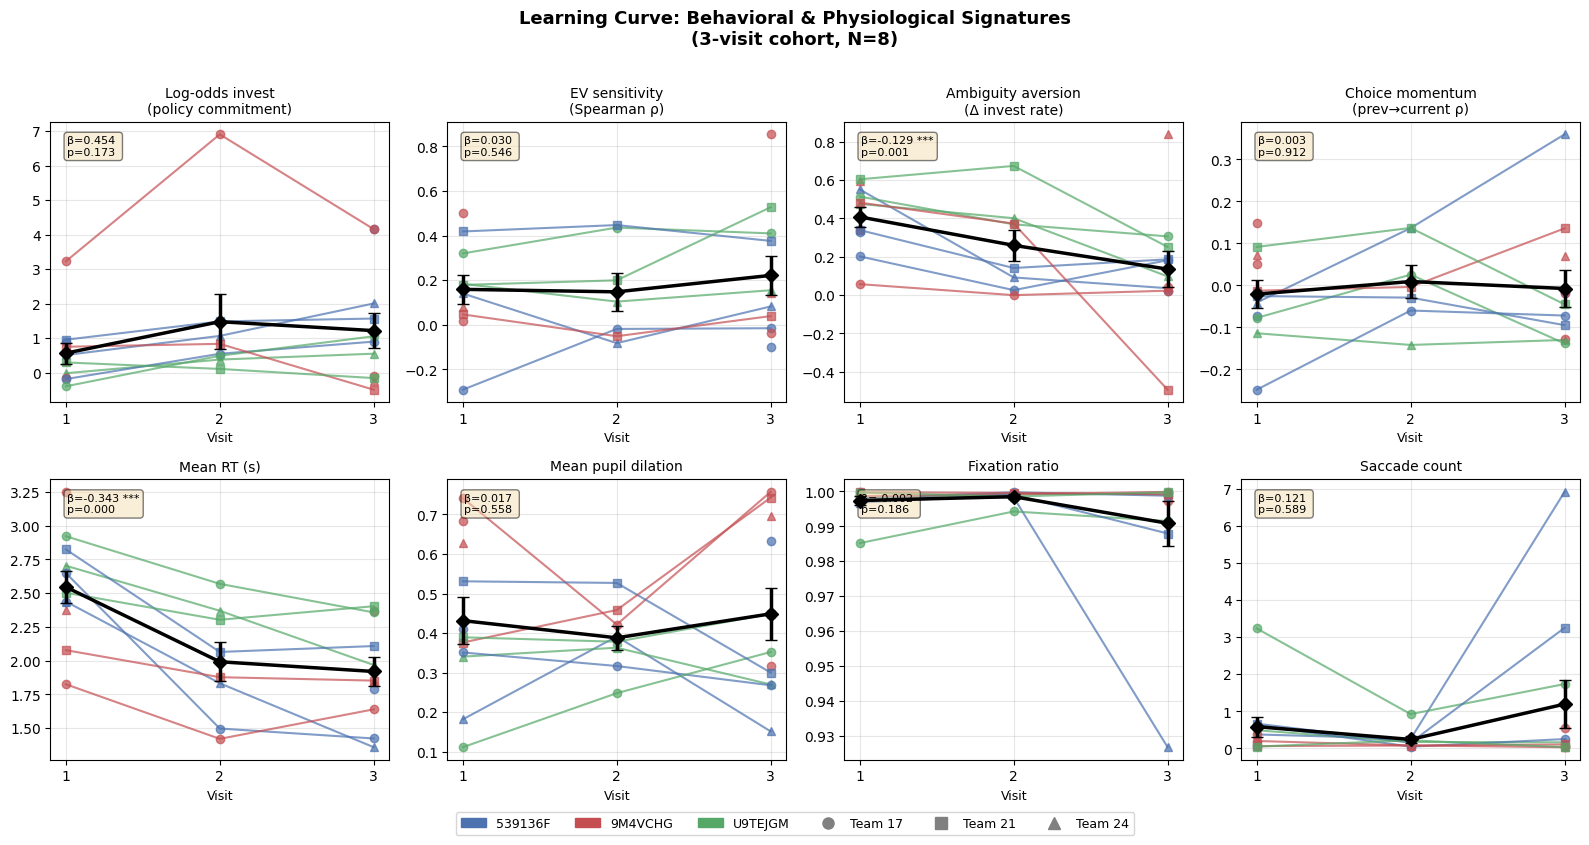

Saved.


In [20]:
plot_sigs = ['log_odds_invest', 'ev_sensitivity', 'ambiguity_aversion',
             'choice_momentum', 'rt_mean', 'pupil_mean', 'fixation_ratio', 'saccade_count']
sig_labels = {
    'log_odds_invest': 'Log-odds invest\n(policy commitment)',
    'ev_sensitivity': 'EV sensitivity\n(Spearman ρ)',
    'ambiguity_aversion': 'Ambiguity aversion\n(Δ invest rate)',
    'choice_momentum': 'Choice momentum\n(prev→current ρ)',
    'rt_mean': 'Mean RT (s)',
    'pupil_mean': 'Mean pupil dilation',
    'fixation_ratio': 'Fixation ratio',
    'saccade_count': 'Saccade count',
}

uid_colors = {'539136F': '#4C72B0', '9M4VCHG': '#C44E52', 'U9TEJGM': '#55A868', 'A6I5HI6': '#8172B2'}
team_markers = {'Team 17': 'o', 'Team 21': 's', 'Team 24': '^'}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, sig in zip(axes, plot_sigs):
    for _, row in cohort_3v.iterrows():
        vals = []
        for v, col in [(1, 'subj_v1'), (2, 'subj_v2'), (3, 'subj_v3')]:
            subj = row[col]
            match = sig_3v[(sig_3v['subject_id'] == subj)]
            vals.append(match[sig].values[0] if len(match) else np.nan)
        color = uid_colors.get(row['user_id'], 'gray')
        marker = team_markers.get(row['team'], 'o')
        ax.plot([1, 2, 3], vals, marker=marker, color=color, alpha=0.7, linewidth=1.5)

    # Group mean ± SE
    grp = sig_3v.groupby('visit_number')[sig].agg(['mean','sem'])
    ax.errorbar(grp.index, grp['mean'], yerr=grp['sem'],
                color='black', linewidth=2.5, capsize=4, zorder=5,
                marker='D', markersize=7, label='Mean ± SE')

    # LMM p-value annotation
    row_res = lmm_res_df[lmm_res_df['signature'] == sig]
    if len(row_res):
        p = row_res['p'].values[0]
        b = row_res['beta_visit'].values[0]
        sig_star = row_res['sig'].values[0]
        ax.text(0.05, 0.95, f'β={b:.3f} {sig_star}\np={p:.3f}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_title(sig_labels.get(sig, sig), fontsize=10)
    ax.set_xlabel('Visit', fontsize=9)
    ax.set_xticks([1, 2, 3])
    ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_uid = [Patch(color=c, label=uid) for uid, c in uid_colors.items() if uid in sig_3v['user_id'].values]
legend_team = [Line2D([0],[0], marker=m, color='gray', label=t, linestyle='None', markersize=8)
               for t, m in team_markers.items() if t in sig_3v['team'].values]
fig.legend(handles=legend_uid + legend_team, loc='lower center',
           ncol=len(legend_uid)+len(legend_team), bbox_to_anchor=(0.5, -0.03), fontsize=9)

fig.suptitle('Learning Curve: Behavioral & Physiological Signatures\n(3-visit cohort, N=8)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curve_3visit_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 7. Subject-Level Pairing: V1 vs V2 (33 matched pairs)

For each signature, paired t-test on the 33 subjects who have both V1 and V2, controlling for session-level effects by comparing the same person's signatures across visits.

In [21]:
paired_rows = []
for _, row in cohort_2v.iterrows():
    s1 = sig_df[sig_df['subject_id'] == row['subj_v1']]
    s2 = sig_df[sig_df['subject_id'] == row['subj_v2']]
    if len(s1) == 0 or len(s2) == 0:
        continue
    r = {'team': row['team'], 'user_id': row['user_id']}
    for sig in sig_cols:
        r[f'{sig}_v1'] = s1[sig].values[0]
        r[f'{sig}_v2'] = s2[sig].values[0]
        r[f'{sig}_delta'] = s2[sig].values[0] - s1[sig].values[0]
    paired_rows.append(r)

paired_df = pd.DataFrame(paired_rows)
print(f"Paired V1-V2 subjects: {len(paired_df)}")

print("\nPaired t-tests (V2 - V1):")
paired_tests = []
for sig in sig_cols:
    v1v = paired_df[f'{sig}_v1'].dropna()
    v2v = paired_df[f'{sig}_v2'].dropna()
    common_idx = v1v.index.intersection(v2v.index)
    if len(common_idx) < 5:
        continue
    t, p = stats.ttest_rel(v1v[common_idx], v2v[common_idx])
    delta_mean = (v2v[common_idx] - v1v[common_idx]).mean()
    delta_se = (v2v[common_idx] - v1v[common_idx]).sem()
    paired_tests.append({'signature': sig, 'delta_mean': delta_mean, 'delta_se': delta_se,
                         't': t, 'p': p, 'n': len(common_idx)})

paired_res = pd.DataFrame(paired_tests).sort_values('p')
paired_res['sig'] = paired_res['p'].apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '†' if p<.1 else '')
print(paired_res.to_string(index=False))

Paired V1-V2 subjects: 19

Paired t-tests (V2 - V1):
         signature  delta_mean  delta_se         t        p  n sig
           rt_mean   -0.445414  0.095258  4.675866 0.000188 19 ***
ambiguity_aversion   -0.177165  0.045648  3.881073 0.001095 19  **
   log_odds_invest    1.476000  0.544478 -2.710853 0.014318 19   *
       invest_rate    0.106326  0.040646 -2.615893 0.017504 19   *
             rt_cv   -0.022681  0.010771  2.105684 0.049535 19   *
   choice_momentum    0.075919  0.039857 -1.904789 0.077559 15   †
     saccade_count   -0.229572  0.231623  0.991143 0.334753 19    
          pupil_cv    0.781416  0.840222 -0.930011 0.364671 19    
    ev_sensitivity    0.028099  0.054512 -0.515467 0.614270 15    
    fixation_ratio    0.000480  0.001018 -0.471644 0.642847 19    
        pupil_mean    0.011992  0.034965 -0.342979 0.735587 19    


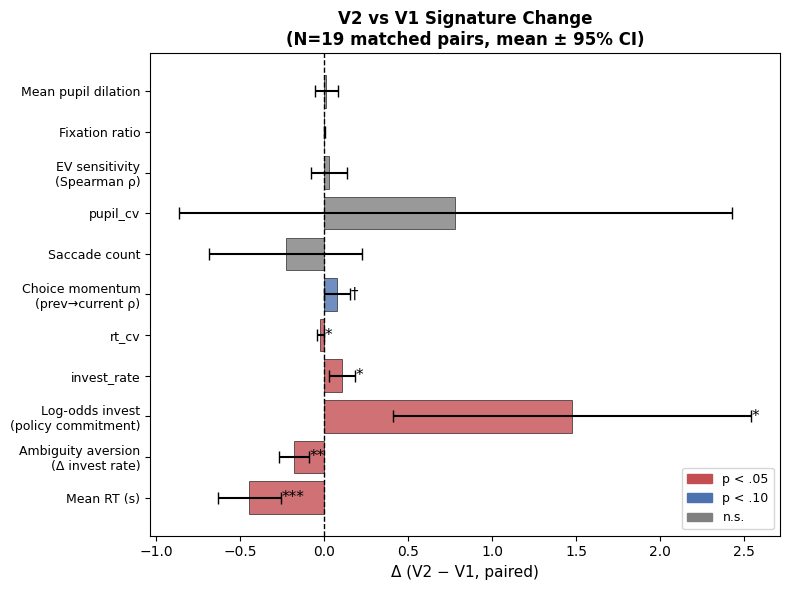

Saved.


In [22]:
# Forest plot: V2-V1 delta with 95% CI for each signature
fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(paired_res))
colors = ['#C44E52' if p < 0.05 else '#4C72B0' if p < 0.1 else 'gray'
          for p in paired_res['p']]

ax.barh(y_pos, paired_res['delta_mean'], xerr=1.96 * paired_res['delta_se'],
        color=colors, alpha=0.8, edgecolor='black', linewidth=0.5, capsize=4)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

for i, (_, r) in enumerate(paired_res.iterrows()):
    if r['sig']:
        ax.text(r['delta_mean'] + 1.96 * r['delta_se'] + 0.002, i,
                r['sig'], va='center', fontsize=11, color='black')

ax.set_yticks(y_pos)
ax.set_yticklabels([sig_labels.get(s, s) for s in paired_res['signature']], fontsize=9)
ax.set_xlabel('Δ (V2 − V1, paired)', fontsize=11)
ax.set_title(f'V2 vs V1 Signature Change\n(N={len(paired_df)} matched pairs, mean ± 95% CI)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#C44E52', label='p < .05'),
    Patch(color='#4C72B0', label='p < .10'),
    Patch(color='gray', label='n.s.'),
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curve_v1v2_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 8. LMM Forest Plot

Summary of visit slopes from the mixed-effects model across all signatures.

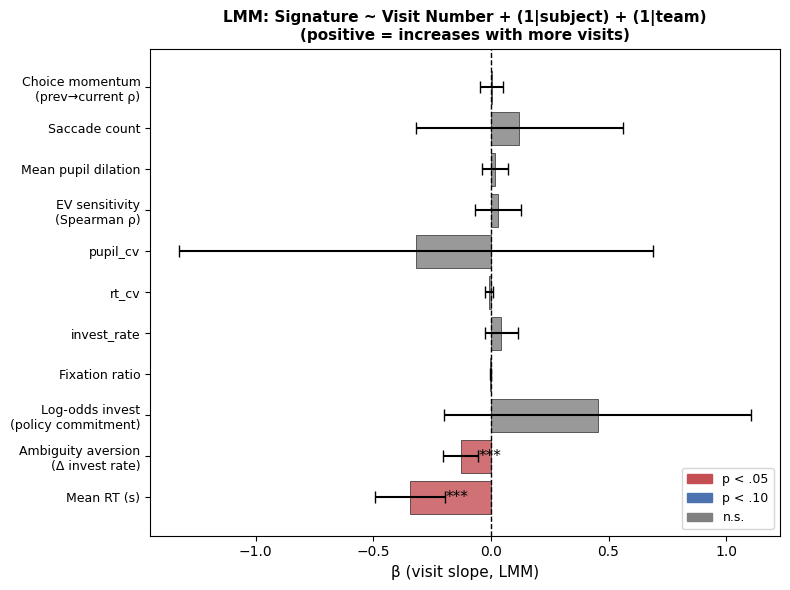

Saved.


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

lmm_sorted = lmm_res_df.sort_values('p')
y_pos = np.arange(len(lmm_sorted))
colors = ['#C44E52' if p < 0.05 else '#4C72B0' if p < 0.1 else 'gray'
          for p in lmm_sorted['p']]

ax.barh(y_pos, lmm_sorted['beta_visit'], xerr=1.96 * lmm_sorted['se'],
        color=colors, alpha=0.8, edgecolor='black', linewidth=0.5, capsize=4)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

for i, (_, r) in enumerate(lmm_sorted.iterrows()):
    if r['sig']:
        ax.text(r['beta_visit'] + 1.96 * r['se'] + 0.001, i,
                r['sig'], va='center', fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels([sig_labels.get(s, s) for s in lmm_sorted['signature']], fontsize=9)
ax.set_xlabel('β (visit slope, LMM)', fontsize=11)
ax.set_title('LMM: Signature ~ Visit Number + (1|subject) + (1|team)\n(positive = increases with more visits)',
             fontsize=11, fontweight='bold')

ax.legend(handles=[
    Patch(color='#C44E52', label='p < .05'),
    Patch(color='#4C72B0', label='p < .10'),
    Patch(color='gray', label='n.s.'),
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curve_lmm_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 9. Save Results

In [24]:
sig_df.to_csv(RESULTS_DIR / f'session_signatures_{TIMEFRAME}.csv', index=False)
lmm_res_df.to_csv(RESULTS_DIR / f'lmm_visit_slopes_{TIMEFRAME}.csv', index=False)
paired_res.to_csv(RESULTS_DIR / f'paired_v1v2_tests_{TIMEFRAME}.csv', index=False)
sig_3v.to_csv(RESULTS_DIR / f'signatures_3visit_cohort_{TIMEFRAME}.csv', index=False)

print(f"All results saved to {RESULTS_DIR}")
print("\n=== SUMMARY ===")
print(f"Session signatures computed for {len(sig_df)} subject-visit pairs")
print(f"3-visit cohort (fully paired): {len(sig_3v)} rows, {len(cohort_3v)} subjects")
print(f"V1+V2 matched pairs: {len(paired_df)}")
print(f"\nSignatures with significant visit slope (LMM p<.05):")
sig_lmm = lmm_res_df[lmm_res_df['p'] < 0.05]
if len(sig_lmm):
    print(sig_lmm[['signature','beta_visit','p','sig']].to_string(index=False))
else:
    print("  None at p<.05")
print(f"\nSignatures with significant V2-V1 change (paired t p<.05):")
sig_paired = paired_res[paired_res['p'] < 0.05]
if len(sig_paired):
    print(sig_paired[['signature','delta_mean','p','sig']].to_string(index=False))
else:
    print("  None at p<.05")

All results saved to ../../data/results/main/learning_curve

=== SUMMARY ===
Session signatures computed for 80 subject-visit pairs
3-visit cohort (fully paired): 30 rows, 11 subjects
V1+V2 matched pairs: 19

Signatures with significant visit slope (LMM p<.05):
         signature  beta_visit        p sig
           rt_mean   -0.342867 0.000006 ***
ambiguity_aversion   -0.128734 0.000817 ***

Signatures with significant V2-V1 change (paired t p<.05):
         signature  delta_mean        p sig
           rt_mean   -0.445414 0.000188 ***
ambiguity_aversion   -0.177165 0.001095  **
   log_odds_invest    1.476000 0.014318   *
       invest_rate    0.106326 0.017504   *
             rt_cv   -0.022681 0.049535   *
